In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/application_train.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
missing_pct = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >40% missing")
df.drop(columns=cols_to_drop, inplace=True)


df.drop(columns=['SK_ID_CURR'], inplace=True)

print("Shape after dropping:", df.shape)

Dropping 49 columns with >40% missing
Shape after dropping: (307511, 72)


In [5]:
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365


df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, 0)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365
df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].clip(lower=0)

df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)

df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

print("New features created!")
print(df[['AGE_YEARS', 'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO', 
          'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 
          'INCOME_PER_PERSON']].head())

New features created!
   AGE_YEARS  YEARS_EMPLOYED  CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  \
0  25.920548        1.745205             2.007879              0.121977   
1  45.931507        3.254795             4.790732              0.132216   
2  52.180822        0.616438             1.999970              0.099999   
3  52.068493        8.326027             2.316150              0.219898   
4  54.608219        8.323288             4.222187              0.179961   

   CREDIT_GOODS_RATIO  INCOME_PER_PERSON  
0            1.158394           101250.0  
1            1.145198            90000.0  
2            0.999993            33750.0  
3            1.052799            45000.0  
4            0.999998            60750.0  


In [6]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f"Total features: {X.shape[1]}")
print(f"Categorical: {len(categorical_cols)}")
print(f"Numerical: {len(numerical_cols)}")
print(f"\nDefault rate: {y.mean():.3f}")

Total features: 77
Categorical: 12
Numerical: 65

Default rate: 0.081


In [7]:
cols_to_remove = ['DAYS_BIRTH', 'DAYS_EMPLOYED']
df.drop(columns=cols_to_remove, inplace=True)

X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Final feature count:", X.shape[1])
print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Final feature count: 75
Categorical: 12
Numerical: 63


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Default rate in train:", y_train.mean().round(3))
print("Default rate in test:", y_test.mean().round(3))

Train size: (246008, 75)
Test size: (61503, 75)
Default rate in train: 0.081
Default rate in test: 0.081


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready!")

Preprocessing pipeline ready!


In [10]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, 
        class_weight='balanced', n_jobs=-1,
        min_samples_leaf=5), 
    
    'XGBoost': XGBClassifier(
        n_estimators=150, random_state=42,
        scale_pos_weight=11, 
        max_depth=6,         
        learning_rate=0.1,   
        eval_metric='logloss', verbosity=0),
    
    'LightGBM': LGBMClassifier(
        n_estimators=150, random_state=42,
        scale_pos_weight=11, 
        max_depth=6, 
        learning_rate=0.1, 
        verbose=-1)
}

results = {}

for name, model in models.items():
    print(f"=Training {name}=")
    
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = {'f1': f1, 'roc_auc': roc, 'pipeline': pipe}
    
   
    print(classification_report(y_test, y_pred, target_names=['Not Default', 'Default']))
    print(f"ROC-AUC Score: {roc:.3f}")
    print("\n" + "-"*40 + "\n")

=Training Logistic Regression=
              precision    recall  f1-score   support

 Not Default       0.96      0.69      0.80     56538
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

ROC-AUC Score: 0.746

----------------------------------------

=Training Random Forest=
              precision    recall  f1-score   support

 Not Default       0.94      0.92      0.93     56538
     Default       0.26      0.31      0.29      4965

    accuracy                           0.87     61503
   macro avg       0.60      0.62      0.61     61503
weighted avg       0.88      0.87      0.88     61503

ROC-AUC Score: 0.747

----------------------------------------

=Training XGBoost=
              precision    recall  f1-score   support

 Not Default       0.96      0.73      0.83     56538
     Default       0.17      0.64 

In [11]:
for name, result in results.items():
    pipe = result['pipeline']
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    print(f"{name}:")
    print(f"  Predicted defaults: {y_pred.sum()} out of {len(y_pred)}")
    print(f"  Actual defaults: {y_test.sum()}")
    print(f"  Avg fraud probability: {y_prob.mean():.3f}")
    print()

Logistic Regression:
  Predicted defaults: 20883 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.423

Random Forest:
  Predicted defaults: 5954 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.295

XGBoost:
  Predicted defaults: 18202 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.390

LightGBM:
  Predicted defaults: 18939 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.395



In [12]:
from sklearn.model_selection import GridSearchCV

tuning_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        random_state=42,
        scale_pos_weight=11,
        verbose=-1))
])

param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 50],
}

grid_search = GridSearchCV(
    tuning_pipe,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__n_estimators': 200, 'model__num_leaves': 31}
Best CV ROC-AUC: 0.75


Tuned LightGBM → F1: 0.270 | ROC-AUC: 0.757

Classification Report:
              precision    recall  f1-score   support

 Not Default       0.96      0.71      0.82     56538
     Default       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503



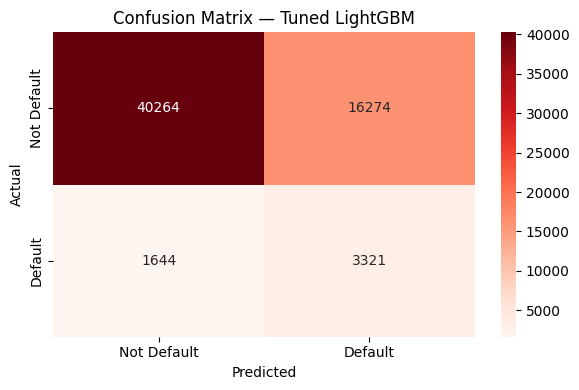

In [13]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

f1_tuned = f1_score(y_test, y_pred_tuned)
roc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"Tuned LightGBM → F1: {f1_tuned:.3f} | ROC-AUC: {roc_tuned:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, 
      target_names=['Not Default', 'Default']))

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Default', 'Default'],
            yticklabels=['Not Default', 'Default'])
plt.title('Confusion Matrix — Tuned LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [14]:
import shap

lgbm_model = best_model.named_steps['model']
preprocessor_fitted = best_model.named_steps['preprocessor']

X_test_transformed = preprocessor_fitted.transform(X_test)

ohe_features = best_model.named_steps['preprocessor']\
    .named_transformers_['cat']['encoder']\
    .get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + ohe_features

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values computed!")
print("Shape:", shap_values.shape)

SHAP values computed!
Shape: (61503, 187)


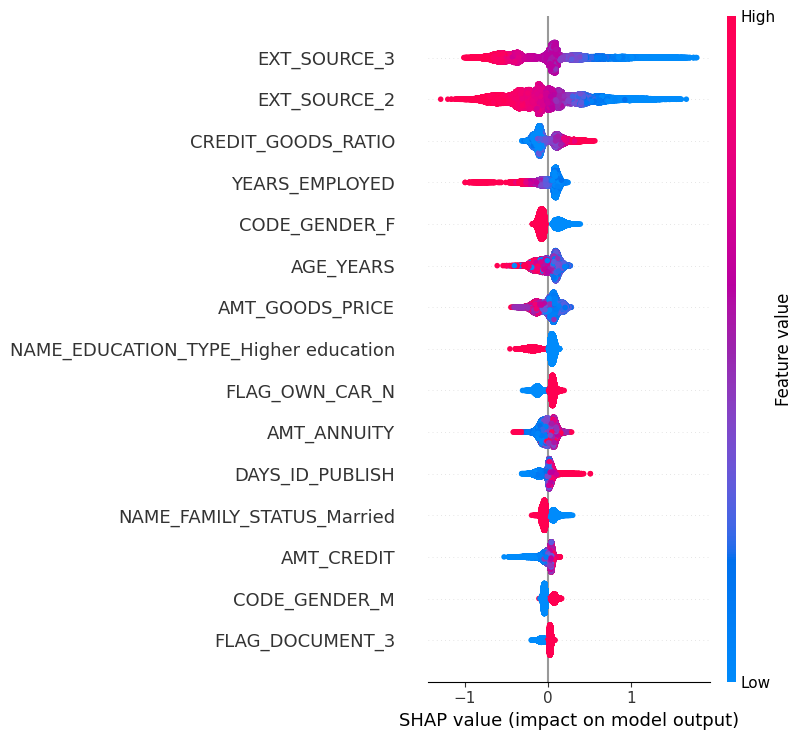

In [15]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_features,
                  max_display=15)

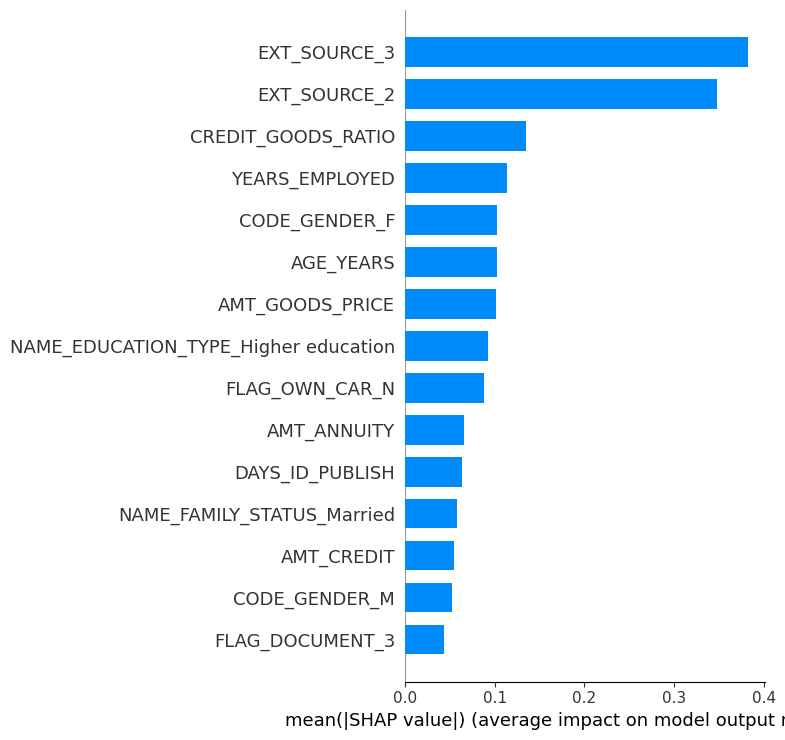

In [16]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_features,
                  plot_type='bar',
                  max_display=15)

In [17]:
import joblib
import os

os.makedirs('../models', exist_ok=True)


joblib.dump(best_model, '../models/loan_default_model.pkl')
joblib.dump(categorical_cols, '../models/categorical_cols.pkl')
joblib.dump(numerical_cols, '../models/numerical_cols.pkl')

print("Model saved!")
print(os.listdir('../models'))

Model saved!
['categorical_cols.pkl', 'loan_default_model.pkl', 'numerical_cols.pkl']


In [18]:
bureau = pd.read_csv('../data/bureau.csv')
print("Shape:", bureau.shape)
print("\nUnique applicants (SK_ID_CURR):", bureau['SK_ID_CURR'].nunique())
print("Total rows:", len(bureau))
print("\nColumns:")
print(bureau.columns.tolist())
bureau.head()

Shape: (1716428, 17)

Unique applicants (SK_ID_CURR): 305811
Total rows: 1716428

Columns:
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [19]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_LOANS=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CREDIT_TYPES=('CREDIT_TYPE', 'nunique'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_MAX_AMT_OVERDUE=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_TOTAL_PROLONG=('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_TOTAL_CREDIT_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
).reset_index()


bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_TOTAL_DEBT'] / (bureau_agg['BUREAU_TOTAL_CREDIT_SUM'] + 1)
)

print("Aggregated shape:", bureau_agg.shape)
print("\nMissing values:")
print(bureau_agg.isnull().sum())
bureau_agg.head()

Aggregated shape: (305811, 13)

Missing values:
SK_ID_CURR                      0
BUREAU_LOAN_COUNT               0
BUREAU_ACTIVE_LOANS             0
BUREAU_CREDIT_TYPES             0
BUREAU_DAYS_CREDIT_MEAN         0
BUREAU_DAYS_CREDIT_MIN          0
BUREAU_MAX_OVERDUE_DAYS         0
BUREAU_MAX_AMT_OVERDUE      92840
BUREAU_TOTAL_PROLONG            0
BUREAU_TOTAL_CREDIT_SUM         0
BUREAU_TOTAL_DEBT               0
BUREAU_TOTAL_OVERDUE            0
BUREAU_DEBT_CREDIT_RATIO        0
dtype: int64


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_LOANS,BUREAU_CREDIT_TYPES,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_MAX_OVERDUE_DAYS,BUREAU_MAX_AMT_OVERDUE,BUREAU_TOTAL_PROLONG,BUREAU_TOTAL_CREDIT_SUM,BUREAU_TOTAL_DEBT,BUREAU_TOTAL_OVERDUE,BUREAU_DEBT_CREDIT_RATIO
0,100001,7,3,1,-735.000000,-1572,0,NaN,0,1453365.000,596686.5,0.0,0.410555
1,100002,8,2,2,-874.000000,-1437,0,5043.645,0,865055.565,245781.0,0.0,0.284121
2,100003,4,1,2,-1400.750000,-2586,0,0.000,0,1017400.500,0.0,0.0,0.000000
3,100004,2,0,1,-867.000000,-1326,0,0.000,0,189037.800,0.0,0.0,0.000000
4,100005,3,2,2,-190.666667,-373,0,0.000,0,657126.000,568408.5,0.0,0.864990


In [20]:
bureau_agg['BUREAU_MAX_AMT_OVERDUE'] = bureau_agg['BUREAU_MAX_AMT_OVERDUE'].fillna(0)
print("Missing after fill:", bureau_agg['BUREAU_MAX_AMT_OVERDUE'].isnull().sum())

Missing after fill: 0


In [21]:
# Reload the original clean application data fresh (before merge)
df = pd.read_csv('../data/application_train.csv')

# Merge bureau aggregates
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')

print("Shape after merge:", df.shape)
print("\nMissing values introduced by merge (applicants with NO bureau record):")
print(df['BUREAU_LOAN_COUNT'].isnull().sum(), "out of", len(df))

Shape after merge: (307511, 134)

Missing values introduced by merge (applicants with NO bureau record):
44020 out of 307511


In [22]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_LOANS=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CREDIT_TYPES=('CREDIT_TYPE', 'nunique'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_MAX_AMT_OVERDUE=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_TOTAL_PROLONG=('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_TOTAL_CREDIT_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
).reset_index()


bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_TOTAL_DEBT'] / (bureau_agg['BUREAU_TOTAL_CREDIT_SUM'] + 1)
)

print("Aggregated shape:", bureau_agg.shape)
print("\nMissing values:")
print(bureau_agg.isnull().sum())
bureau_agg.head()

Aggregated shape: (305811, 13)

Missing values:
SK_ID_CURR                      0
BUREAU_LOAN_COUNT               0
BUREAU_ACTIVE_LOANS             0
BUREAU_CREDIT_TYPES             0
BUREAU_DAYS_CREDIT_MEAN         0
BUREAU_DAYS_CREDIT_MIN          0
BUREAU_MAX_OVERDUE_DAYS         0
BUREAU_MAX_AMT_OVERDUE      92840
BUREAU_TOTAL_PROLONG            0
BUREAU_TOTAL_CREDIT_SUM         0
BUREAU_TOTAL_DEBT               0
BUREAU_TOTAL_OVERDUE            0
BUREAU_DEBT_CREDIT_RATIO        0
dtype: int64


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_LOANS,BUREAU_CREDIT_TYPES,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_MAX_OVERDUE_DAYS,BUREAU_MAX_AMT_OVERDUE,BUREAU_TOTAL_PROLONG,BUREAU_TOTAL_CREDIT_SUM,BUREAU_TOTAL_DEBT,BUREAU_TOTAL_OVERDUE,BUREAU_DEBT_CREDIT_RATIO
0,100001,7,3,1,-735.000000,-1572,0,NaN,0,1453365.000,596686.5,0.0,0.410555
1,100002,8,2,2,-874.000000,-1437,0,5043.645,0,865055.565,245781.0,0.0,0.284121
2,100003,4,1,2,-1400.750000,-2586,0,0.000,0,1017400.500,0.0,0.0,0.000000
3,100004,2,0,1,-867.000000,-1326,0,0.000,0,189037.800,0.0,0.0,0.000000
4,100005,3,2,2,-190.666667,-373,0,0.000,0,657126.000,568408.5,0.0,0.864990


In [23]:
df['NO_BUREAU_HISTORY'] = df['BUREAU_LOAN_COUNT'].isnull().astype(int)

zero_fill_cols = [
    'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_CREDIT_TYPES',
    'BUREAU_TOTAL_PROLONG', 'BUREAU_TOTAL_CREDIT_SUM', 'BUREAU_TOTAL_DEBT',
    'BUREAU_TOTAL_OVERDUE', 'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_MAX_AMT_OVERDUE',
    'BUREAU_DEBT_CREDIT_RATIO'
]
df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

print("Remaining missing per bureau column:")
print(df[['NO_BUREAU_HISTORY'] + zero_fill_cols + 
         ['BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MIN']].isnull().sum())

Remaining missing per bureau column:
NO_BUREAU_HISTORY               0
BUREAU_LOAN_COUNT               0
BUREAU_ACTIVE_LOANS             0
BUREAU_CREDIT_TYPES             0
BUREAU_TOTAL_PROLONG            0
BUREAU_TOTAL_CREDIT_SUM         0
BUREAU_TOTAL_DEBT               0
BUREAU_TOTAL_OVERDUE            0
BUREAU_MAX_OVERDUE_DAYS         0
BUREAU_MAX_AMT_OVERDUE          0
BUREAU_DEBT_CREDIT_RATIO        0
BUREAU_DAYS_CREDIT_MEAN     44020
BUREAU_DAYS_CREDIT_MIN      44020
dtype: int64


In [24]:
bureau_features = [
    'NO_BUREAU_HISTORY', 'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS',
    'BUREAU_CREDIT_TYPES', 'BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MIN',
    'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_MAX_AMT_OVERDUE', 'BUREAU_TOTAL_PROLONG',
    'BUREAU_TOTAL_CREDIT_SUM', 'BUREAU_TOTAL_DEBT', 'BUREAU_TOTAL_OVERDUE',
    'BUREAU_DEBT_CREDIT_RATIO'
]

correlations = df[bureau_features + ['TARGET']].corr()['TARGET'].drop('TARGET')
correlations_sorted = correlations.sort_values(key=abs, ascending=False)

print("Bureau feature correlation with TARGET (sorted by strength):")
print(correlations_sorted)

Bureau feature correlation with TARGET (sorted by strength):
BUREAU_DAYS_CREDIT_MEAN     0.089729
BUREAU_DAYS_CREDIT_MIN      0.075248
BUREAU_ACTIVE_LOANS         0.043569
NO_BUREAU_HISTORY           0.030789
BUREAU_CREDIT_TYPES        -0.019160
BUREAU_TOTAL_CREDIT_SUM    -0.018020
BUREAU_TOTAL_OVERDUE        0.011943
BUREAU_LOAN_COUNT          -0.010020
BUREAU_MAX_OVERDUE_DAYS     0.004360
BUREAU_TOTAL_DEBT           0.001895
BUREAU_TOTAL_PROLONG        0.001772
BUREAU_MAX_AMT_OVERDUE      0.001772
BUREAU_DEBT_CREDIT_RATIO    0.000326
Name: TARGET, dtype: float64


In [25]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_LOANS=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CREDIT_TYPES=('CREDIT_TYPE', 'nunique'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_MAX_AMT_OVERDUE=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_TOTAL_PROLONG=('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_TOTAL_CREDIT_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
).reset_index()


bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_TOTAL_DEBT'] / (bureau_agg['BUREAU_TOTAL_CREDIT_SUM'] + 1)
)

print("Aggregated shape:", bureau_agg.shape)
print("\nMissing values:")
print(bureau_agg.isnull().sum())
bureau_agg.head()

Aggregated shape: (305811, 13)

Missing values:
SK_ID_CURR                      0
BUREAU_LOAN_COUNT               0
BUREAU_ACTIVE_LOANS             0
BUREAU_CREDIT_TYPES             0
BUREAU_DAYS_CREDIT_MEAN         0
BUREAU_DAYS_CREDIT_MIN          0
BUREAU_MAX_OVERDUE_DAYS         0
BUREAU_MAX_AMT_OVERDUE      92840
BUREAU_TOTAL_PROLONG            0
BUREAU_TOTAL_CREDIT_SUM         0
BUREAU_TOTAL_DEBT               0
BUREAU_TOTAL_OVERDUE            0
BUREAU_DEBT_CREDIT_RATIO        0
dtype: int64


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_LOANS,BUREAU_CREDIT_TYPES,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_MAX_OVERDUE_DAYS,BUREAU_MAX_AMT_OVERDUE,BUREAU_TOTAL_PROLONG,BUREAU_TOTAL_CREDIT_SUM,BUREAU_TOTAL_DEBT,BUREAU_TOTAL_OVERDUE,BUREAU_DEBT_CREDIT_RATIO
0,100001,7,3,1,-735.000000,-1572,0,NaN,0,1453365.000,596686.5,0.0,0.410555
1,100002,8,2,2,-874.000000,-1437,0,5043.645,0,865055.565,245781.0,0.0,0.284121
2,100003,4,1,2,-1400.750000,-2586,0,0.000,0,1017400.500,0.0,0.0,0.000000
3,100004,2,0,1,-867.000000,-1326,0,0.000,0,189037.800,0.0,0.0,0.000000
4,100005,3,2,2,-190.666667,-373,0,0.000,0,657126.000,568408.5,0.0,0.864990


In [26]:
prev_app = pd.read_csv('../data/previous_application.csv')
print("Shape:", prev_app.shape)
print("\nUnique applicants (SK_ID_CURR):", prev_app['SK_ID_CURR'].nunique())
print("Total rows:", len(prev_app))
print("\nColumns:")
print(prev_app.columns.tolist())
prev_app.head()

Shape: (1670214, 37)

Unique applicants (SK_ID_CURR): 338857
Total rows: 1670214

Columns:
['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
prev_app_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_PREV', 'count'),
    PREV_APPROVED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELLED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),  # ← fixed spelling
    PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    PREV_DAYS_DECISION_MIN=('DAYS_DECISION', 'min'),
    PREV_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    PREV_RATE_DOWN_PAYMENT_MEAN=('RATE_DOWN_PAYMENT', 'mean'),
).reset_index()

prev_app_agg['PREV_CREDIT_APPLICATION_RATIO'] = (
    prev_app_agg['PREV_AMT_CREDIT_MEAN'] / (prev_app_agg['PREV_AMT_APPLICATION_MEAN'] + 1)
)
prev_app_agg['PREV_REFUSAL_RATE'] = (
    prev_app_agg['PREV_REFUSED_COUNT'] / (prev_app_agg['PREV_APP_COUNT'] + 1)
)

print("Aggregated shape:", prev_app_agg.shape)
print("PREV_CANCELLED_COUNT distribution after fix:")
print(prev_app_agg['PREV_CANCELLED_COUNT'].describe())

Aggregated shape: (338857, 14)
PREV_CANCELLED_COUNT distribution after fix:
count    338857.000000
mean          0.933488
std           1.723006
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          58.000000
Name: PREV_CANCELLED_COUNT, dtype: float64


In [28]:
print([col for col in df.columns if 'PREV_' in col or 'BUREAU_' in col])

['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_CREDIT_TYPES', 'BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_MIN', 'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_MAX_AMT_OVERDUE', 'BUREAU_TOTAL_PROLONG', 'BUREAU_TOTAL_CREDIT_SUM', 'BUREAU_TOTAL_DEBT', 'BUREAU_TOTAL_OVERDUE', 'BUREAU_DEBT_CREDIT_RATIO', 'NO_BUREAU_HISTORY']


In [30]:
# Step 1: explicit flag for "no previous Home Credit application at all"
df['NO_PREV_APPLICATION'] = df['PREV_APP_COUNT'].isnull().astype(int)

# Step 2: zero-fill the true-zero columns (counts and ratios that are genuinely 0 when no history exists)
prev_zero_fill_cols = [
    'PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT',
    'PREV_CANCELLED_COUNT', 'PREV_REFUSAL_RATE'
]
df[prev_zero_fill_cols] = df[prev_zero_fill_cols].fillna(0)

# Step 3: leave these as NaN for the pipeline's SimpleImputer(median) —
# these aren't true zeros, they're "no applicable value to average"
# PREV_DAYS_DECISION_MEAN, PREV_DAYS_DECISION_MIN, PREV_AMT_APPLICATION_MEAN,
# PREV_AMT_CREDIT_MEAN, PREV_AMT_ANNUITY_MEAN, PREV_CNT_PAYMENT_MEAN,
# PREV_RATE_DOWN_PAYMENT_MEAN, PREV_CREDIT_APPLICATION_RATIO

print("Remaining missing per previous_application column:")
prev_all_cols = [
    'NO_PREV_APPLICATION'] + prev_zero_fill_cols + [
    'PREV_DAYS_DECISION_MEAN', 'PREV_DAYS_DECISION_MIN',
    'PREV_AMT_APPLICATION_MEAN', 'PREV_AMT_CREDIT_MEAN',
    'PREV_AMT_ANNUITY_MEAN', 'PREV_CNT_PAYMENT_MEAN',
    'PREV_RATE_DOWN_PAYMENT_MEAN', 'PREV_CREDIT_APPLICATION_RATIO'
]
print(df[prev_all_cols].isnull().sum())

KeyError: 'PREV_APP_COUNT'

In [31]:
prev_features = [
    'NO_PREV_APPLICATION', 'PREV_APP_COUNT', 'PREV_APPROVED_COUNT',
    'PREV_REFUSED_COUNT', 'PREV_CANCELLED_COUNT', 'PREV_REFUSAL_RATE',
    'PREV_DAYS_DECISION_MEAN', 'PREV_DAYS_DECISION_MIN',
    'PREV_AMT_APPLICATION_MEAN', 'PREV_AMT_CREDIT_MEAN',
    'PREV_AMT_ANNUITY_MEAN', 'PREV_CNT_PAYMENT_MEAN',
    'PREV_RATE_DOWN_PAYMENT_MEAN', 'PREV_CREDIT_APPLICATION_RATIO'
]

correlations_prev = df[prev_features + ['TARGET']].corr()['TARGET'].drop('TARGET')
correlations_prev_sorted = correlations_prev.sort_values(key=abs, ascending=False)

print("Previous application feature correlation with TARGET (sorted by strength):")
print(correlations_prev_sorted)

KeyError: "['NO_PREV_APPLICATION', 'PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT', 'PREV_CANCELLED_COUNT', 'PREV_REFUSAL_RATE', 'PREV_DAYS_DECISION_MEAN', 'PREV_DAYS_DECISION_MIN', 'PREV_AMT_APPLICATION_MEAN', 'PREV_AMT_CREDIT_MEAN', 'PREV_AMT_ANNUITY_MEAN', 'PREV_CNT_PAYMENT_MEAN', 'PREV_RATE_DOWN_PAYMENT_MEAN', 'PREV_CREDIT_APPLICATION_RATIO'] not in index"

In [32]:
print(df['PREV_CANCELLED_COUNT'].value_counts())
print("\nStd dev:", df['PREV_CANCELLED_COUNT'].std())


KeyError: 'PREV_CANCELLED_COUNT'

In [ ]:
print(prev_app['NAME_CONTRACT_STATUS'].value_counts())

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


In [33]:
df = pd.read_csv('../data/application_train.csv')

df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
df['NO_BUREAU_HISTORY'] = df['BUREAU_LOAN_COUNT'].isnull().astype(int)
bureau_zero_fill_cols = [
    'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_CREDIT_TYPES',
    'BUREAU_TOTAL_PROLONG', 'BUREAU_TOTAL_CREDIT_SUM', 'BUREAU_TOTAL_DEBT',
    'BUREAU_TOTAL_OVERDUE', 'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_MAX_AMT_OVERDUE',
    'BUREAU_DEBT_CREDIT_RATIO'
]
df[bureau_zero_fill_cols] = df[bureau_zero_fill_cols].fillna(0)

df = df.merge(prev_app_agg, on='SK_ID_CURR', how='left')
df['NO_PREV_APPLICATION'] = df['PREV_APP_COUNT'].isnull().astype(int)
prev_zero_fill_cols = [
    'PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT',
    'PREV_CANCELLED_COUNT', 'PREV_REFUSAL_RATE'
]
df[prev_zero_fill_cols] = df[prev_zero_fill_cols].fillna(0)

print("Final shape:", df.shape)
print("Duplicate columns check:", df.columns[df.columns.duplicated()].tolist())
print("\nAny _x or _y suffixed columns remaining:")
print([col for col in df.columns if col.endswith('_x') or col.endswith('_y')])
print("\nPREV_CANCELLED_COUNT distribution:")
print(df['PREV_CANCELLED_COUNT'].describe())
print("\nCorrelation with TARGET:")
print(df[['PREV_CANCELLED_COUNT', 'TARGET']].corr())

Final shape: (307511, 149)
Duplicate columns check: []

Any _x or _y suffixed columns remaining:
[]

PREV_CANCELLED_COUNT distribution:
count    307511.000000
mean          0.843680
std           1.642287
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          58.000000
Name: PREV_CANCELLED_COUNT, dtype: float64

Correlation with TARGET:
                      PREV_CANCELLED_COUNT    TARGET
PREV_CANCELLED_COUNT              1.000000  0.020757
TARGET                            0.020757  1.000000


In [34]:
import pandas as pd
import numpy as np

# ── Reload base data ─────────────────────────────────────────
df = pd.read_csv('../data/application_train.csv')

# ── Build bureau aggregates ──────────────────────────────────
bureau = pd.read_csv('../data/bureau.csv')
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_LOANS=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CREDIT_TYPES=('CREDIT_TYPE', 'nunique'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_MAX_AMT_OVERDUE=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_TOTAL_PROLONG=('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_TOTAL_CREDIT_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
).reset_index()
bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_TOTAL_DEBT'] / (bureau_agg['BUREAU_TOTAL_CREDIT_SUM'] + 1)
)
bureau_agg['BUREAU_MAX_AMT_OVERDUE'] = bureau_agg['BUREAU_MAX_AMT_OVERDUE'].fillna(0)

# ── Build previous_application aggregates ────────────────────
prev_app = pd.read_csv('../data/previous_application.csv')
prev_app_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_PREV', 'count'),
    PREV_APPROVED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELLED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    PREV_DAYS_DECISION_MIN=('DAYS_DECISION', 'min'),
    PREV_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    PREV_RATE_DOWN_PAYMENT_MEAN=('RATE_DOWN_PAYMENT', 'mean'),
).reset_index()
prev_app_agg['PREV_CREDIT_APPLICATION_RATIO'] = (
    prev_app_agg['PREV_AMT_CREDIT_MEAN'] / (prev_app_agg['PREV_AMT_APPLICATION_MEAN'] + 1)
)
prev_app_agg['PREV_REFUSAL_RATE'] = (
    prev_app_agg['PREV_REFUSED_COUNT'] / (prev_app_agg['PREV_APP_COUNT'] + 1)
)

# ── Merge both onto df ────────────────────────────────────────
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
df['NO_BUREAU_HISTORY'] = df['BUREAU_LOAN_COUNT'].isnull().astype(int)
bureau_zero_fill_cols = [
    'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_CREDIT_TYPES',
    'BUREAU_TOTAL_PROLONG', 'BUREAU_TOTAL_CREDIT_SUM', 'BUREAU_TOTAL_DEBT',
    'BUREAU_TOTAL_OVERDUE', 'BUREAU_MAX_OVERDUE_DAYS', 'BUREAU_MAX_AMT_OVERDUE',
    'BUREAU_DEBT_CREDIT_RATIO'
]
df[bureau_zero_fill_cols] = df[bureau_zero_fill_cols].fillna(0)

df = df.merge(prev_app_agg, on='SK_ID_CURR', how='left')
df['NO_PREV_APPLICATION'] = df['PREV_APP_COUNT'].isnull().astype(int)
prev_zero_fill_cols = [
    'PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT',
    'PREV_CANCELLED_COUNT', 'PREV_REFUSAL_RATE'
]
df[prev_zero_fill_cols] = df[prev_zero_fill_cols].fillna(0)

print("Enriched shape:", df.shape)
print("Duplicate columns:", df.columns[df.columns.duplicated()].tolist())

Enriched shape: (307511, 149)
Duplicate columns: []


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Drop columns with more than 40% missing (same threshold as original)
missing_pct = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >40% missing")
df.drop(columns=cols_to_drop, inplace=True)

df.drop(columns=['SK_ID_CURR'], inplace=True)

# Original feature engineering (unchanged)
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, 0)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365
df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].clip(lower=0)
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

X[categorical_cols] = X[categorical_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTotal features: {X.shape[1]}")
print(f"Categorical: {len(categorical_cols)}")
print(f"Numerical: {len(numerical_cols)}")
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Default rate train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Dropping 49 columns with >40% missing

Total features: 102
Categorical: 12
Numerical: 90

Train: (246008, 102) | Test: (61503, 102)
Default rate train: 0.081 | test: 0.081


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready for enriched feature set")

Preprocessing pipeline ready for enriched feature set


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42,
        class_weight='balanced_subsample', n_jobs=-1, min_samples_leaf=50),
    'XGBoost': XGBClassifier(
        n_estimators=200, random_state=42, scale_pos_weight=11,
        max_depth=4, learning_rate=0.05,
        eval_metric='logloss', verbosity=0),
    'LightGBM': LGBMClassifier(
        n_estimators=200, random_state=42, scale_pos_weight=11,
        max_depth=4, learning_rate=0.05, verbose=-1)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results[name] = {'f1': round(f1, 3), 'roc_auc': round(roc, 3), 'pipeline': pipe}
    print(f"{name:25s} → F1: {f1:.3f} | ROC-AUC: {roc:.3f}\n")

Training Logistic Regression...
Logistic Regression       → F1: 0.266 | ROC-AUC: 0.757

Training Random Forest...
Random Forest             → F1: 0.298 | ROC-AUC: 0.757

Training XGBoost...
XGBoost                   → F1: 0.278 | ROC-AUC: 0.764

Training LightGBM...
LightGBM                  → F1: 0.277 | ROC-AUC: 0.764



In [38]:
from sklearn.model_selection import GridSearchCV

lgbm_tuning_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42, scale_pos_weight=11, verbose=-1))
])

lgbm_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 50],
}

lgbm_grid = GridSearchCV(
    lgbm_tuning_pipe, lgbm_param_grid,
    cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
lgbm_grid.fit(X_train, y_train)

print("LightGBM best params:", lgbm_grid.best_params_)
print("LightGBM best CV ROC-AUC:", round(lgbm_grid.best_score_, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
LightGBM best params: {'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__n_estimators': 200, 'model__num_leaves': 31}
LightGBM best CV ROC-AUC: 0.762


Tuned LightGBM (enriched features) → F1: 0.279 | ROC-AUC: 0.770

Classification Report:
              precision    recall  f1-score   support

 Not Default       0.96      0.72      0.83     56538
     Default       0.18      0.67      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.72      0.78     61503



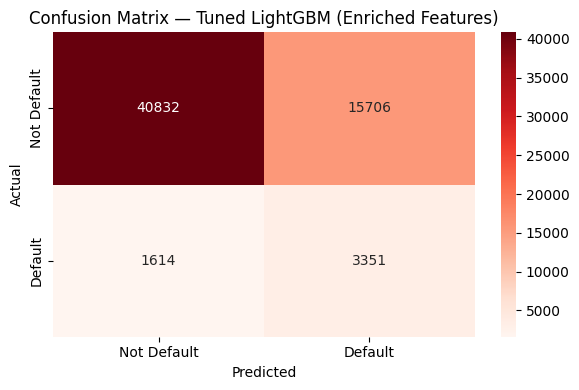

In [39]:
best_model = lgbm_grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

f1_tuned = f1_score(y_test, y_pred_tuned)
roc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"Tuned LightGBM (enriched features) → F1: {f1_tuned:.3f} | ROC-AUC: {roc_tuned:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Not Default', 'Default']))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Default', 'Default'],
            yticklabels=['Not Default', 'Default'])
plt.title('Confusion Matrix — Tuned LightGBM (Enriched Features)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()